In [1]:
import numpy as np
import numpy.random as nprand
import matplotlib.pyplot as plt
from scipy.stats import gamma
import matplotlib.colors as mcolors

In [ ]:
### --- TEST FUNCTION PL BETTER RSI --- ###
def g(x, y,epsilon):
    return 0.5*(0.5*x**2 - y)**2 + 0.5*epsilon *x**2

# --- Gradient ---
def grad_g(x, y,epsilon):
    return np.array([x*(0.5*x**2 - y)+epsilon*x, -(0.5*x**2 - y)])
bound_square = 1.2638
x_vals = np.linspace(-bound_square, bound_square, 1000)
y_vals = np.linspace(-bound_square, bound_square, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
epsilon = 0.1

Z = g(X, Y,epsilon)
# Gradient sur la grille
U, V = grad_g(X, Y,epsilon)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
Q1[mask] = inner_prod[mask] / (np.sqrt(norm_x2[mask])*np.sqrt(norm_grad2[mask]))

mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

mask = Z > 1e-12
Q3[mask] =np.sqrt(norm_grad2[mask] / norm_x2[mask])
print("PL :",Q2.min(), "Angle :", Q1.min(), "EB :", Q3.min())
# --- Affichage ---
fig, ax = plt.subplots(2, 2, figsize=(20, 12))

# Surface f(x,y)
ax1 = fig.add_subplot(2,2,1, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
# ax1.contour(X, Y, Z)
ax1.set_title("Surface de f(x,y)")

ax2 = fig.add_subplot(2,2,2)
# Z = np.array([-20,0,20])
# divnorm = mcolors.TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
im1 = ax2.contourf(X, Y, Q1, levels=30, cmap="cividis")
ax2.set_title("Angle")
fig.colorbar(im1, ax=ax2)

ax3 = fig.add_subplot(2,2,3)
divnorm = mcolors.TwoSlopeNorm(vmin=(Q2-Q1).min(), vcenter=0, vmax=(Q2-Q1).max())
im2 = ax3.contourf(X, Y, Q2-Q1, levels=30, cmap="seismic", norm=divnorm, origin="lower")
ax3.set_title("PL-RSI")
fig.colorbar(im2, ax=ax3)

# ax4 = fig.add_subplot(2,2,4)
# ax4.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
# ax4.quiver(X, Y, U, V, color="red")
# ax4.set_title("Champ de gradient de f")
ax4 = fig.add_subplot(2,2,4)
im3 = ax4.contourf(X, Y, Q2-Q3, levels=30, cmap="cividis")
ax4.set_title("PL-EB")
fig.colorbar(im3, ax=ax4)

plt.tight_layout()
plt.show()

PL : 0.03760390021979999 RSI : 9.249268012099387e-05 EB : 0.05129315086538839


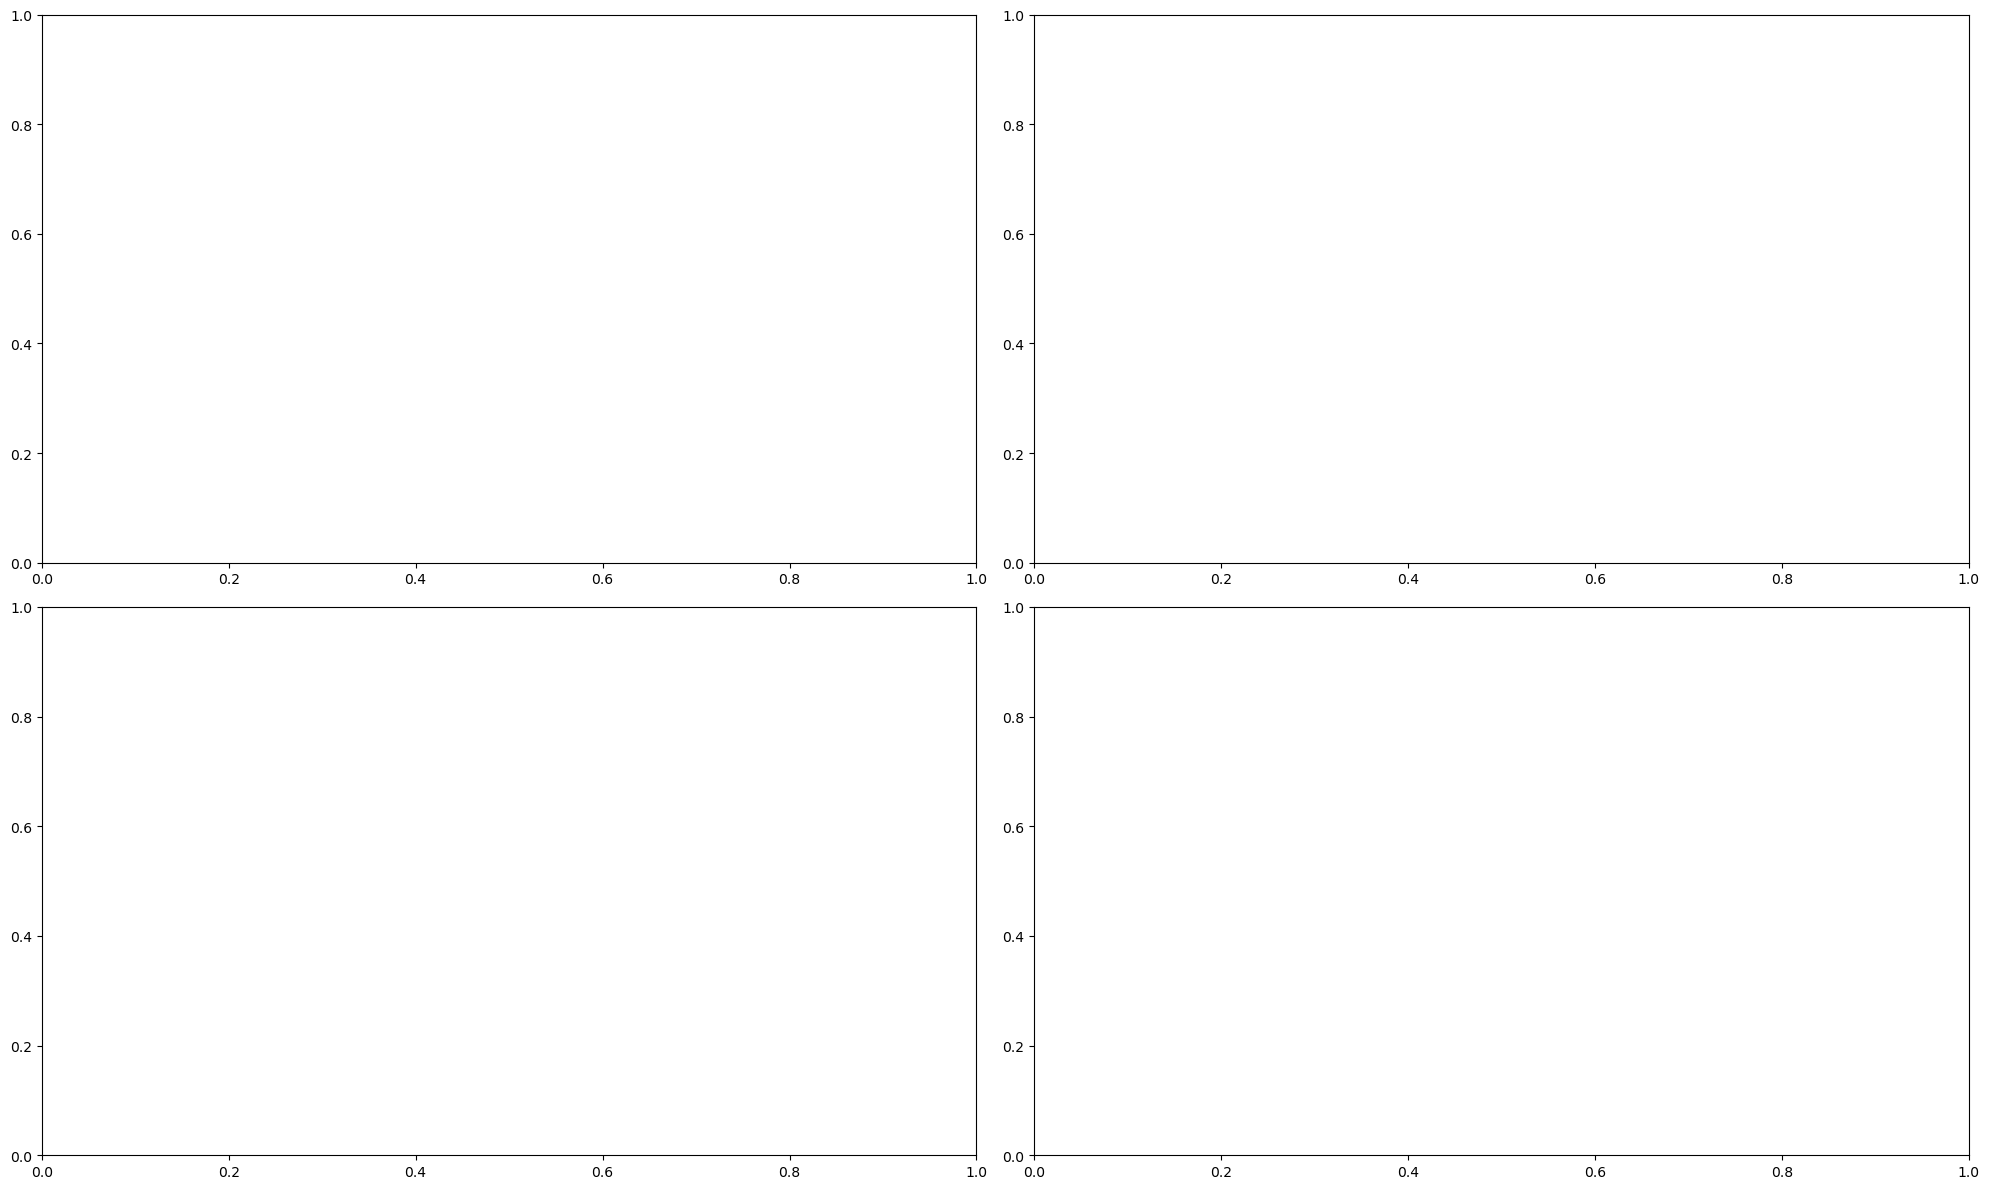

In [ ]:
### --- FOR PLOT --- ###
def g(x, y,epsilon):
    return 0.5*(0.5*x**2 - y)**2 + 0.5*epsilon *x**2

# --- Gradient ---
def grad_g(x, y,epsilon):
    return np.array([x*(0.5*x**2 - y)+epsilon*x, -(0.5*x**2 - y)])

   
# bound_square = 1.2
bound_square = 1.2638
x_vals = np.linspace(-bound_square, bound_square, 1000)
y_vals = np.linspace(-bound_square, bound_square, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
epsilon = 0.1

Z = g(X, Y,epsilon)
# Gradient sur la grille
U, V = grad_g(X, Y,epsilon)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
Q1[mask] = inner_prod[mask] / norm_x2[mask]

mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

mask = Z > 1e-12
Q3[mask] =np.sqrt(norm_grad2[mask] / norm_x2[mask])
print("PL :",Q2.min(), "RSI :", Q1.min(), "EB :", Q3.min())
# --- Affichage ---
fig, ax = plt.subplots(2, 2, figsize=(20, 12))

fig1 = plt.figure()
ax1 = fig1.add_subplot(111, projection="3d")
norm = PowerNorm(gamma=0.6, vmin=Z.min(), vmax=Z.max()) 
ax1.view_init(elev=30, azim=-60)
ax1.plot_surface(X, Y, Z, cmap="hot", alpha=0.8,antialiased=False,norm=norm)
# ax1.set_title("Surface de f(x,y)")
ax1.scatter3D(0,0,0,label =":  Unique Minimizer",color="black",marker="x",s=100)
ax1.set_zticks([])
ax1.set_xticks([-1,1])
ax1.set_yticks([-0.2,1])
ax1.set_xlabel(r'$x$',labelpad=-10)
ax1.set_ylabel(r'$y$',labelpad=-10)
ax1.set_zlabel(r'$f(x,y)$',labelpad=-10)
ax1.legend(edgecolor=(1,1,1),fontsize=fontsize,handletextpad=-0.1)
fig1.savefig("figures/surface_fx_y.png", dpi=300, bbox_inches="tight")
plt.close(fig1)  # ferme la figure après sauvegarde
divnorm = mcolors.TwoSlopeNorm(vmin=(Q2/Q1).min(), vcenter=1, vmax=(Q2/Q1).max())
# --- Deuxième plot : contour Angle ---
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
im1 = ax2.contourf(X, Y, Q2/Q1, levels=30, cmap="viridis", norm=mcolors.LogNorm(vmin=(Q2/Q1).min(), vmax=(Q2/Q1).max()), origin="lower")
# ax2.set_xticks([-bound_square,bound_square])
# ax2.set_yticks([-bound_square,bound_square])
ax2.set_xticks([-1,1])
ax2.set_yticks([-1,1])
ax2.set_title(r'$\log(\mu(x)/RSI(x))$')
fig2.colorbar(im1, ax=ax2)
fig2.tight_layout()
fig2.savefig("figures/angle.png", dpi=300)
plt.close(fig2)
plt.tight_layout()
plt.show()

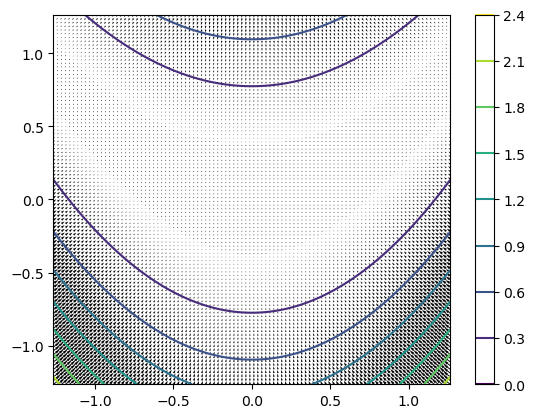

In [ ]:
# plt.quiver(
#     X, Y, -U, -V,
#    density=0.8,
#     maxlength=0.1,
#     minlength=0.02,
#     color = np.log(Z),
#     linewidth=1, 
#     cmap='winter',
#     arrowstyle='fancy'
# )
def g(x, y,epsilon):
    return 0.5*(0.5*x**2 - y)**2 + 0.5*epsilon *x**2

# --- Gradient ---
def grad_g(x, y,epsilon):
    return np.array([x*(0.5*x**2 - y)+epsilon*x, -(0.5*x**2 - y)])
bound_square = 1.2638
x_vals = np.linspace(-bound_square, bound_square, 100)
y_vals = np.linspace(-bound_square, bound_square, 100)
X, Y = np.meshgrid(x_vals, y_vals)
epsilon = 0.1

Z = g(X, Y,epsilon)
U, V = grad_g(X, Y,epsilon)
# Gradient sur la grille
plt.quiver(
    X, Y, -U, -V,
)
xx = np.linspace(-bound_square,bound_square)
plt.contour(X,Y,Z)
plt.colorbar()
# plt.contour(X,Y,Z,levels=20)

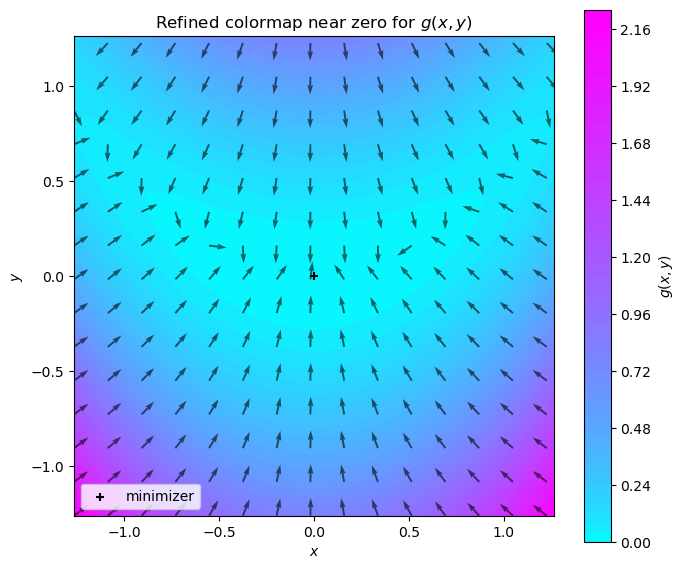

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

def g(x, y, epsilon):
    return 0.5 * (0.5 * x**2 - y)**2 + 0.5 * epsilon * x**2

def grad_g(x, y, epsilon):
    return np.array([x * (0.5 * x**2 - y) + epsilon * x,
                     -(0.5 * x**2 - y)])

# --- Paramètres ---
epsilon = 0.1
bound_square = 1.2638
n_grid = 200  # grille plus fine pour meilleure précision

x_vals = np.linspace(-bound_square, bound_square, n_grid)
y_vals = np.linspace(-bound_square, bound_square, n_grid)
X, Y = np.meshgrid(x_vals, y_vals)

Z = g(X, Y, epsilon)
U, V = grad_g(X, Y, epsilon)

# Normalisation des vecteurs (pour direction uniquement)
norm = np.sqrt(U**2 + V**2) + 1e-8
U_n = U / norm
V_n = V / norm

plt.figure(figsize=(7, 6))

# --- Colormap raffinée autour de zéro ---
# gamma < 1 => plus de contraste près de zéro
norm_cm = PowerNorm(gamma=0.7, vmin=Z.min(), vmax=Z.max())

contours = plt.contourf(
    X, Y, Z,
    levels=60,             # Beaucoup de niveaux !
    cmap="cool",
    norm=norm_cm
)
plt.colorbar(contours, label=r"$g(x,y)$")

# Champ de gradient
step = 14
plt.quiver(
    X[::step, ::step], Y[::step, ::step],
    -U_n[::step, ::step], -V_n[::step, ::step],
    alpha=0.6, color ="red",facecolor ="black"
)
plt.scatter(0,0,color="black",marker="+",label = "minimizer")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Refined colormap near zero for $g(x,y)$")
plt.legend()
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()



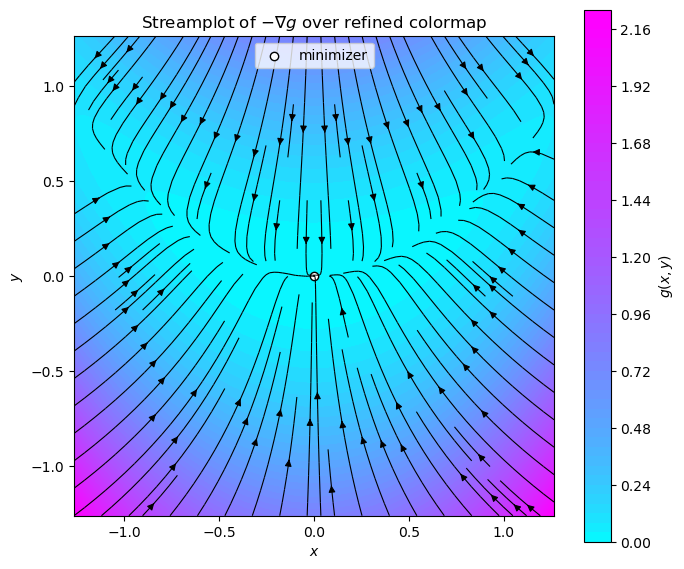

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

def g(x, y, epsilon):
    return 0.5 * (0.5 * x**2 - y)**2 + 0.5 * epsilon * x**2

def grad_g(x, y, epsilon):
    return np.array([
        x * (0.5 * x**2 - y) + epsilon * x,
        -(0.5 * x**2 - y)
    ])

# --- Paramètres ---
epsilon = 0.1
bound_square = 1.2638
n_grid = 200

x_vals = np.linspace(-bound_square, bound_square, n_grid)
y_vals = np.linspace(-bound_square, bound_square, n_grid)
X, Y = np.meshgrid(x_vals, y_vals)

Z = g(X, Y, epsilon)
U, V = grad_g(X, Y, epsilon)

plt.figure(figsize=(7, 6))

# Colormap raffinée
norm_cm = PowerNorm(gamma=0.7, vmin=Z.min(), vmax=Z.max())
contours = plt.contourf(
    X, Y, Z,
    levels=60,
    cmap="cool",
    norm=norm_cm
)
plt.colorbar(contours, label=r"$g(x,y)$")

# --- Champ de gradient avec streamplot ---
plt.streamplot(
    X, Y,
    -U, -V,                 # flots de descente de gradient
    color="black",
    density=1.2,            # densité des lignes
    linewidth=0.8,
    arrowsize=1
)

plt.scatter(0, 0, color="white", edgecolor="black", marker="o", label="minimizer")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Streamplot of $-\nabla g$ over refined colormap")
plt.legend()
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()


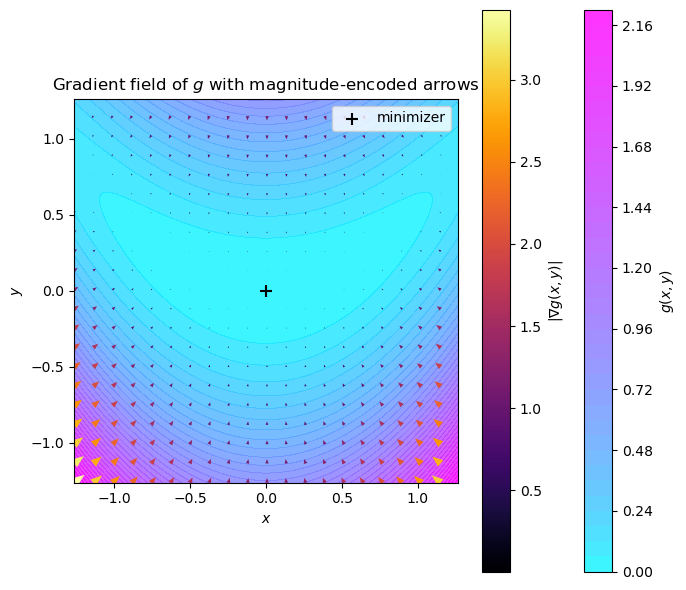

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

def g(x, y, epsilon):
    return 0.5 * (0.5 * x**2 - y)**2 + 0.5 * epsilon * x**2

def grad_g(x, y, epsilon):
    return np.array([
        x * (0.5 * x**2 - y) + epsilon * x,
        -(0.5 * x**2 - y)
    ])

# --- Paramètres ---
epsilon = 0.1
bound_square = 1.2638
n_grid = 200

x_vals = np.linspace(-bound_square, bound_square, n_grid)
y_vals = np.linspace(-bound_square, bound_square, n_grid)
X, Y = np.meshgrid(x_vals, y_vals)

Z = g(X, Y, epsilon)
U, V = grad_g(X, Y, epsilon)
norm_grad = np.sqrt(U**2 + V**2)

plt.figure(figsize=(7, 6))

# Fond : contours assez discrets
norm_cm = PowerNorm(gamma=0.7, vmin=Z.min(), vmax=Z.max())
contours = plt.contourf(
    X, Y, Z,
    levels=40,
    cmap="cool",
    norm=norm_cm,
    alpha=0.8
)
plt.colorbar(contours, label=r"$g(x,y)$")

# Sous-échantillonnage pour les flèches
step = 10
Xs = X[::step, ::step]
Ys = Y[::step, ::step]
Us = -U[::step, ::step]
Vs = -V[::step, ::step]
Ns = norm_grad[::step, ::step]

# Champ de gradient :
#  - longueur ∝ norme
#  - couleur ∝ norme
q = plt.quiver(
    Xs, Ys, Us, Vs,
    Ns,                          # couleur = norme
    cmap="inferno",
    angles="xy",
    scale_units="xy",
    scale=40,                    # joue avec ça pour la taille globale
    width=0.007,
    headwidth=3.5,
    headlength=4.5,
    minlength=0.1
)
cbar2 = plt.colorbar(q, label=r"$\|\nabla g(x,y)\|$")

plt.scatter(0, 0, color="black", marker="+", s=80, label="minimizer")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Gradient field of $g$ with magnitude-encoded arrows")
plt.legend(loc="upper right")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()


In [95]:
L = 0
for x in x_vals:
    for y in y_vals:
        L=max(0,L_smooth(x, y,epsilon))

In [96]:
#-- Calcul (tau,mu) sqc --# 

def g(x, y,epsilon):
    return 0.5*(0.5*x**2 - y)**2 + 0.5*epsilon *x**2

# --- Gradient ---
def grad_g(x, y,epsilon):
    return np.array([x*(0.5*x**2 - y)+epsilon*x, -(0.5*x**2 - y)])

# --- Hessian ---
def L_smooth(x, y,epsilon):
    hess_matrix = np.array([[3/2*x**2+epsilon-y, -x],[-x,1]])  
    L = np.max(np.abs(np.linalg.eig(hess_matrix)[0]))
    return L
bound_square = 1.2638
x_vals = np.linspace(-bound_square, bound_square, 1000)
y_vals = np.linspace(-bound_square, bound_square, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
epsilon = 0.1

Z = g(X, Y,epsilon)
# Gradient sur la grille
U, V = grad_g(X, Y,epsilon)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2
gamma = 0.001
# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
gamma = np.linspace(1*10**-6,0.002,1000)
gf_bound = np.empty(1000)
nmo_bound = np.empty(1000)
gd_bound = np.empty(1000)
nm_bound = np.empty(1000)
k = 0
for i in gamma:
    Q1[mask] = -2*(Z[mask]- i**(-1)*inner_prod[mask]) / norm_x2[mask]
    gf_bound[k] = i*Q1.min()
    nmo_bound[k] = i*np.sqrt(Q1.min())
    gd_bound[k] = i*Q1.min()/L
    nm_bound[k] = i*np.sqrt(Q1.min()/L)
    k+=1
# plt.contourf(X, Y, Q1, levels=30, cmap="cividis")
mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])
print(np.nanmax(gd_bound),np.nanmax(nm_bound))

/tmp/ipykernel_16463/524382730.py:55: RuntimeWarning: invalid value encountered in sqrt
  nmo_bound[k] = i*np.sqrt(Q1.min())
/tmp/ipykernel_16463/524382730.py:57: RuntimeWarning: invalid value encountered in sqrt
  nm_bound[k] = i*np.sqrt(Q1.min()/L)


7.751445233775267e-05 0.00018457770464610755


In [97]:
print(Q2.min()/L)

0.01576614277177604


In [98]:
### --- TEST FUNCTION PL BETTER RSI --- ###
def g(x, y,epsilon):
    return 0.5*(0.5*x**2 - y)**2 + 0.5*epsilon *x**2

# --- Gradient ---
def grad_g(x, y,epsilon):
    return np.array([x*(0.5*x**2 - y)+epsilon*x, -(0.5*x**2 - y)])
# --- Hessian ---
def L_smooth(x, y,epsilon):
    hess_matrix = np.array([[3/2*x**2+epsilon-y, -x],[-x,1]])  
    L = np.max(np.abs(np.linalg.eig(hess_matrix)[0]))
    return L

def norm(x):
    return np.sqrt(np.sum(x**2))
epsilon = 0.1

n_iter = 10**4
x_gd = np.empty((2,n_iter))
x_gd[:,0] = [-1,1]
f_gd = np.empty(n_iter)
f_gd[0] = g(x_gd[0,0],x_gd[1,0],epsilon)
gamma = 1/L
corr = np.empty(n_iter)
corr[0] = np.sum(grad_g(x_gd[0,0],x_gd[1,0],epsilon)*np.array([x_gd[0,0],x_gd[1,0]]))/(norm(grad_g(x_gd[0,0],x_gd[1,0],epsilon))*norm(np.array([x_gd[0,0],x_gd[1,0]])))
avg_corr = 0
for i in range(1,n_iter):
    x_gd[:,i] = x_gd[:,i-1] - gamma*grad_g(x_gd[0,i-1],x_gd[1,i-1],epsilon) 
    f_gd[i] = g(x_gd[0,i],x_gd[1,i],epsilon)
    corr[i] = np.sum(grad_g(x_gd[0,i],x_gd[1,i],epsilon)*np.array([x_gd[0,i],x_gd[1,i]]))/(norm(grad_g(x_gd[0,i],x_gd[1,i],epsilon))*norm(np.array([x_gd[0,i],x_gd[1,i]])))
    avg_corr += np.exp(0.1*i)*(corr[i]-0.9999999999999999)
print(avg_corr/n_iter)

nan


/tmp/ipykernel_16463/3199689673.py:31: RuntimeWarning: overflow encountered in exp
  avg_corr += np.exp(0.1*i)*(corr[i]-0.9999999999999999)
/tmp/ipykernel_16463/3199689673.py:31: RuntimeWarning: invalid value encountered in scalar add
  avg_corr += np.exp(0.1*i)*(corr[i]-0.9999999999999999)
/tmp/ipykernel_16463/3199689673.py:31: RuntimeWarning: invalid value encountered in scalar multiply
  avg_corr += np.exp(0.1*i)*(corr[i]-0.9999999999999999)
/tmp/ipykernel_16463/3199689673.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  corr[i] = np.sum(grad_g(x_gd[0,i],x_gd[1,i],epsilon)*np.array([x_gd[0,i],x_gd[1,i]]))/(norm(grad_g(x_gd[0,i],x_gd[1,i],epsilon))*norm(np.array([x_gd[0,i],x_gd[1,i]])))
/tmp/ipykernel_16463/3199689673.py:30: RuntimeWarning: invalid value encountered in scalar divide
  corr[i] = np.sum(grad_g(x_gd[0,i],x_gd[1,i],epsilon)*np.array([x_gd[0,i],x_gd[1,i]]))/(norm(grad_g(x_gd[0,i],x_gd[1,i],epsilon))*norm(np.array([x_gd[0,i],x_gd[1,i]])))


In [82]:
corr_

NameError: name 'corr_' is not defined

/tmp/ipykernel_16463/2157405929.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(f_gd))


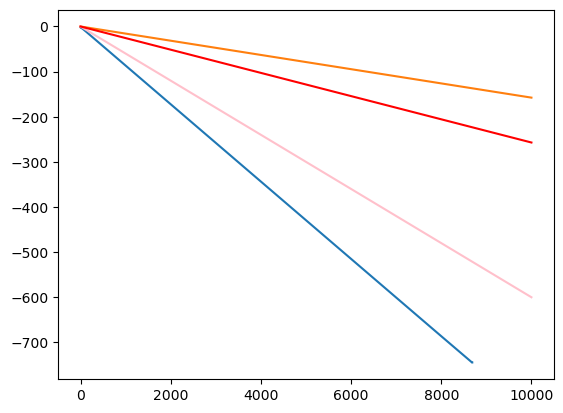

In [103]:
axx = np.arange(n_iter)
plt.plot(np.log(f_gd))
plt.plot(axx,-axx*Q2.min()/L)
plt.plot(axx,-axx*0.06,color="pink")
plt.plot(axx,-axx*np.sqrt(Q2.min()*epsilon)/L,color="red")